# **Box Office Analysis for New Movie Studio**📽️

![Box office](images/Box_office.png)

## Business Problem 💼

![movie](images/business_understanding.png)

Over the last few years, the entertainment sector has seen a remarkable change, with large corporations investing in original video content to gain and maintain audience interest. As a response to this trend, my company seeks to establish a new film studio to venture into this competitive market. 
By leveraging on data from different movie sources, I aim to identify the characteristics associated with strong box office performance and translate these findings into actionable insights to inform the studio's original content strategy.

## Objectives
- Identify the film genres, production budgets, and release periods most strongly associated with box office success.
- Develop data-driven recommendations for genre selection, and release timing for new film projects.
- Support strategic decision-making for the new movie studio by providing actionable insights based on historical box office data.

## Data Understanding 📁

![img](images/data_understanding.png)

The data for this project emanates from multiple sources, some of which include:
- [**Box Office Mojo**](https://www.boxofficemojo.com/): Gross revenue data for movies.
- [**IMDb**](https://www.imdb.com/): Information about genres, ratings, directors, and release dates.
- [**The Numbers**](https://www.the-numbers.com/): Budget estimates and more detailed financial data.

The datasets include information such as:
- Movie title
- Genre(s)
- Box office earnings
- Production budget
- Release date
- IMDb rating

## Project Workflow 📊
1. **Understanding the problem**: Review and understand the business problem, which is to identify the film types that succeed at the box office

2. **Data collection and understanding**: 
    - Collect the datasets from platforms such as Box Mojo, IMDB and Rotten Tomatoes
    - Understand the data:
        - im.db(movie_basics and movie_ratings)
        - bom.movie_gross.csv
    - Establlish relevant data attributes to implement: `genres, runtime_minutes, start_year, movie_title, average_rating, etc`

3. **Data Cleaning**: Deal with missing values and duplicates in the dataset, standardize column formats, feature engineering, and removing incomplete or inconsistent records.

4. **Exploratory Data Analysis**: Perform Univariate and Bivariate analysis e.g., genre vs revenue, correlation heatmaps to establish correlations between the different numerical columns, bar plots, box plots, histograms.

5. **Data-driven insights and recommendations**: From the analysis, establish the top performing genres with reasonable production budgets.

Now that we have a full understanding of the project and the data, let's dive into the code!🚀

In [ ]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3

In [3]:
# connect to the SQLite database
conn = sqlite3.connect('data/im.db')

# view the tables in the database
q_read_data = """SELECT name 
                 FROM sqlite_master 
                 WHERE type = 'table';"""
pd.read_sql(q_read_data, conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


The `im.db` database contains a number of tables, which include:
- **movie_basics**
- **directors**
- **known_for**
- **movie_akas**
- **movir_ratings**
- **persons**
- **principals**
- **writers**

In [4]:
# read data from all tables in the database
# movie_basics table
q_movie_basics = """SELECT *
                    FROM movie_basics"""
movie_basics_df = pd.read_sql(q_movie_basics, conn)
movie_basics_df

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [14]:
# check the info of the movies_basics dataframe
movie_basics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146144 entries, 0 to 146143
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   movie_id         146144 non-null  object 
 1   primary_title    146144 non-null  object 
 2   original_title   146123 non-null  object 
 3   start_year       146144 non-null  int64  
 4   runtime_minutes  114405 non-null  float64
 5   genres           140736 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.7+ MB


The `movie_basics` table contains a total of 146,144 entries, and a total of 6 columns, including `movie_id, primary_title, original_title, start_year, runtime_minutes, and genres`

In [5]:
# directors table
q_directors = """SELECT *
                 FROM directors"""
directors_df = pd.read_sql(q_directors, conn)
directors_df

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0462036,nm1940585
2,tt0835418,nm0151540
3,tt0835418,nm0151540
4,tt0878654,nm0089502
...,...,...
291169,tt8999974,nm10122357
291170,tt9001390,nm6711477
291171,tt9001494,nm10123242
291172,tt9001494,nm10123248


In [6]:
# known-for table
q_known_for = """SELECT *
                 FROM known_for"""
known_for_df = pd.read_sql(q_known_for, conn)
known_for_df

,person_id,movie_id
0,nm0061671,tt0837562
1,nm0061671,tt2398241
2,nm0061671,tt0844471
3,nm0061671,tt0118553
4,nm0061865,tt0896534
...,...,...
1638255,nm9990690,tt9090932
1638256,nm9990690,tt8737130
1638257,nm9991320,tt8734436
1638258,nm9991320,tt9615610


In [7]:
# movies_akas table
q_movies_akas = """SELECT *
                 FROM movies_akas"""
movies_akas_df = pd.read_sql(q_movie_basics, conn)
movies_akas_df

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


In [8]:
# movie_ratings table
q_movie_ratings = """SELECT *
                 FROM movie_ratings"""
movie_ratings_df = pd.read_sql(q_movie_ratings, conn)
movie_ratings_df

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


In [15]:
# check the info for movie_ratings table
movie_ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


The `movie_ratings` table contains a total of 73856 entries, with a total of 3 columns, including `movie_id, averagerating, and numvotes`

In [9]:
# persons table
q_persons = """SELECT *
               FROM persons"""
persons_df = pd.read_sql(q_persons, conn)
persons_df

,person_id,primary_name,birth_year,death_year,primary_profession
0,nm0061671,Mary Ellen Bauder,NaN,NaN,"miscellaneous,production_manager,producer"
1,nm0061865,Joseph Bauer,NaN,NaN,"composer,music_department,sound_department"
2,nm0062070,Bruce Baum,NaN,NaN,"miscellaneous,actor,writer"
3,nm0062195,Axel Baumann,NaN,NaN,"camera_department,cinematographer,art_department"
4,nm0062798,Pete Baxter,NaN,NaN,"production_designer,art_department,set_decorator"
...,...,...,...,...,...
606643,nm9990381,Susan Grobes,NaN,NaN,actress
606644,nm9990690,Joo Yeon So,NaN,NaN,actress
606645,nm9991320,Madeline Smith,NaN,NaN,actress
606646,nm9991786,Michelle Modigliani,NaN,NaN,producer


In [10]:
# principals table
q_principals = """SELECT *
                  FROM principals"""
principals_df = pd.read_sql(q_principals, conn)
principals_df

,movie_id,ordering,person_id,category,job,characters
0,tt0111414,1,nm0246005,actor,None,"[""The Man""]"
1,tt0111414,2,nm0398271,director,None,None
2,tt0111414,3,nm3739909,producer,producer,None
3,tt0323808,10,nm0059247,editor,None,None
4,tt0323808,1,nm3579312,actress,None,"[""Beth Boothby""]"
...,...,...,...,...,...,...
1028181,tt9692684,1,nm0186469,actor,None,"[""Ebenezer Scrooge""]"
1028182,tt9692684,2,nm4929530,self,None,"[""Herself"",""Regan""]"
1028183,tt9692684,3,nm10441594,director,None,None
1028184,tt9692684,4,nm6009913,writer,writer,None


In [11]:
# writers table
q_writers = """SELECT *
               FROM writers"""
writers_df = pd.read_sql(q_writers, conn)
writers_df

,movie_id,person_id
0,tt0285252,nm0899854
1,tt0438973,nm0175726
2,tt0438973,nm1802864
3,tt0462036,nm1940585
4,tt0835418,nm0310087
...,...,...
255868,tt8999892,nm10122246
255869,tt8999974,nm10122357
255870,tt9001390,nm6711477
255871,tt9004986,nm4993825


In this project, I will be utilizing the `im.db` database, as well as the `bom.movie_gross.csv` dataset for my analysis. In the database, I will specifically use the `movie_basics` and `movie_ratings` tables.

In the database, we can combine the `movie_basics` and `movie_ratings` since they share a common column, which is `movie_id`

In [37]:
# join the movie_basics and movie_ratings tables
q_join = """SELECT b.movie_id, b.primary_title, b.start_year, b.runtime_minutes, b.genres, r.averagerating, r.numvotes
            FROM movie_basics AS b
            INNER JOIN movie_ratings AS r
            ON b.movie_id = r.movie_id
            """

join_movie_df = pd.read_sql(q_join, conn)
join_movie_df.head(10)

,movie_id,primary_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,2013,175.0,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,114.0,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,122.0,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,NaN,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,2017,80.0,"Comedy,Drama,Fantasy",6.5,119
5,tt0112502,Bigfoot,2017,NaN,"Horror,Thriller",4.1,32
6,tt0137204,Joe Finds Grace,2017,83.0,"Adventure,Animation,Comedy",8.1,263
7,tt0146592,Pál Adrienn,2010,136.0,Drama,6.8,451
8,tt0154039,So Much for Justice!,2010,100.0,History,4.6,64
9,tt0159369,Cooper and Hemingway: The True Gen,2013,180.0,Documentary,7.6,53


In [38]:
# check the info of the joined dataframe
join_movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   start_year       73856 non-null  int64  
 3   runtime_minutes  66236 non-null  float64
 4   genres           73052 non-null  object 
 5   averagerating    73856 non-null  float64
 6   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 3.9+ MB


From the info above, we can see that the joined dataframe has a total of 73,856 records, and 7 columns. The columns are:
- movie_id
- primary_title
- start_year
- runtime_minutes
- genres
- averagerating
- numvotes

However, some of the columns have missing values. Let's look more into the null values as well as duplicates in our dataframe.

In [39]:
# check for null values in the joined dataframe as a percentage for each column
null_percentage = (join_movie_df.isnull().sum() / len(join_movie_df)) * 100
null_percentage[null_percentage > 0].sort_values(ascending=False)

runtime_minutes    10.317374
genres              1.088605
dtype: float64

From the above code, we can see that there are columns with missing values. Setting a threshold of 30% for the missing values, none of the columns have reached that threshold, therefore we can either drop some of the rows, or fill the missing values. In order to perform this operation, I will create a function that will deal with the missing values.

In [40]:
# check for duplicates in the joined dataframe
duplicates = join_movie_df.duplicated().sum()
duplicates

np.int64(0)

The joined dataframe has no duplicates, but some of the columns have missing values, which we shall address.

In [48]:
# function to clean missing values
def clean_missing_values(df):
    # fill missing values in 'genres' with unknown
    join_movie_df['genres'].fillna('unknown', inplace=True)

    # fill missing values in 'runtime_minutes' with the mean
    join_movie_df['runtime_minutes'].fillna(join_movie_df['runtime_minutes'].mean(), inplace=True)
    
    return df

In [49]:
# create a new dataframe for the cleaned data
join_movie_df_clean = clean_missing_values(join_movie_df)

# check the info of the cleaned dataframe
join_movie_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         73856 non-null  object 
 1   primary_title    73856 non-null  object 
 2   start_year       73856 non-null  int64  
 3   runtime_minutes  73856 non-null  float64
 4   genres           73856 non-null  object 
 5   averagerating    73856 non-null  float64
 6   numvotes         73856 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 3.9+ MB


/tmp/ipykernel_2142/492998619.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  join_movie_df['runtime_minutes'].fillna(join_movie_df['runtime_minutes'].mean(), inplace=True)


Next, I will check the unique values in the dataframe, specifically in the `genres`, `start_year` and `averagerating` columns.

In [50]:
# function to check unique values in a column
def check_unique_values(df, column_name, show_counts=True):
    """
    Prints the number of unique values in a column, 
    and optionally displays value counts.
    
    Parameters:
    df (DataFrame): Your pandas DataFrame
    column_name (str): Name of the column to check
    show_counts (bool): Whether to display counts of each unique value
    """
    # checks for the column name in dataframe
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found in DataFrame.")
        return
    
    # number of unique values in the column
    unique_values = df[column_name].nunique()
    print(f"Number of unique values in '{column_name}': {unique_values}")
    
    # checks for unique values in each category
    if show_counts:
        print("\nValue counts:")
        print(df[column_name].value_counts())


In [67]:
# unique values in the 'genres' column
check_unique_values(join_movie_df_clean, 'genres')

Number of unique values in 'genres': 924

Value counts:
genres
Drama                        11612
Documentary                  10313
Comedy                        5613
Horror                        2692
Comedy,Drama                  2617
                             ...  
Comedy,Crime,Sci-Fi              1
Action,Adventure,Sport           1
Comedy,Music,Thriller            1
Drama,Short                      1
Documentary,Family,Sci-Fi        1
Name: count, Length: 924, dtype: int64


In [68]:
# unique values in the start_year column
check_unique_values(join_movie_df_clean, 'start_year')

Number of unique values in 'start_year': 10

Value counts:
start_year
2016    8721
2017    8713
2015    8494
2014    8371
2013    7990
2012    7680
2018    7526
2011    7389
2010    6792
2019    2180
Name: count, dtype: int64


In [69]:
# unique values in the averagerating column
check_unique_values(join_movie_df_clean, 'averagerating')

Number of unique values in 'averagerating': 91

Value counts:
averagerating
7.0     2262
6.6     2251
7.2     2249
6.8     2239
6.5     2221
        ... 
9.6       18
10.0      16
9.8       15
9.7       12
9.9        5
Name: count, Length: 91, dtype: int64


We can look into the columns in this table and do some feature engineering to make the columns similar.

In [70]:
# check the columns
join_movie_df_clean.columns

Index(['movie_id', 'primary_title', 'start_year', 'runtime_minutes', 'genres',
       'averagerating', 'numvotes'],
      dtype='object')

Looking at the columns, we can rename `averagerating` and `numvotes` to follow the same convention as the other columns.

In [71]:
# rename columns
join_movie_df_clean = join_movie_df_clean.rename(
    columns = {
        'averagerating': 'average_rating',
        'numvotes': 'number_of_votes'
    }
)
join_movie_df_clean.head()

,movie_id,primary_title,start_year,runtime_minutes,genres,average_rating,number_of_votes
0,tt0063540,Sunghursh,2013,175.00000,"Action,Crime,Drama",7.0,77
1,tt0066787,One Day Before the Rainy Season,2019,114.00000,"Biography,Drama",7.2,43
2,tt0069049,The Other Side of the Wind,2018,122.00000,Drama,6.9,4517
3,tt0069204,Sabse Bada Sukh,2018,94.65404,"Comedy,Drama",6.1,13
4,tt0100275,The Wandering Soap Opera,2017,80.00000,"Comedy,Drama,Fantasy",6.5,119


### Next, we can look into the `bom.movie_gross.csv` dataset and look into it's info.

In [93]:
# read the movie_gross data
movie_gross_db = pd.read_csv('data/bom.movie_gross.csv')
movie_gross_db

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010
...,...,...,...,...,...
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018


In [94]:
# check the info for movie_gross table
movie_gross_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


The `movie_gross` table contains a total of 3387 entries, with a total of 5 columns.

From the dataset, we can see the foreign_gross column is of `object` Data type. We need to convert it to it's correct format, which is float.

In [95]:
# convert foreign_gross column to numeric
movie_gross_db['foreign_gross'] = pd.to_numeric(
    movie_gross_db['foreign_gross'].replace({'\$': '', ',': ''}, regex=True),
    errors='coerce'
)

# round the foreign_gross column to the nearest integer
movie_gross_db['foreign_gross'] = movie_gross_db['foreign_gross'].round(0)

# check the info of the movie_gross dataframe
movie_gross_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2142/1027788016.py:3: SyntaxWarning: invalid escape sequence '\$'
  movie_gross_db['foreign_gross'].replace({'\$': '', ',': ''}, regex=True),


Next, we check for missing values and duplicates in the dataset

In [96]:
# check for null values in the movie_gross dataframe as a percentage for each column
null_percentage_gross = (movie_gross_db.isnull().sum() / len(movie_gross_db)) * 100
null_percentage_gross[null_percentage_gross > 0].sort_values(ascending=False)

foreign_gross     39.858282
domestic_gross     0.826690
studio             0.147623
dtype: float64

In [97]:
# check for duplicates in the movie_gross dataframe
movie_gross_db.duplicated().sum()

np.int64(0)

The movie_gross dataset does not contain any duplicates. However, some columns contain missing values.
We can deal with the missing values using the following methods:
- **Drop rows**: this will be done for the `domestic_gross` and `studio` columns since they have a small percentage of missing values
- **Use Mean**: for the `foreign_gross` column, we can fill the missing values with the mean.

To do this, we can create a function that will clean the columns as stipulated.

In [98]:
# function to clean the data
def clean_movie_gross_data(df):
    # fill missing values in 'foreign_gross' with the mean
    movie_gross_db['foreign_gross'].fillna(movie_gross_db['foreign_gross'].mean(), inplace=True)

    # remove the rows with missing values in 'domestic_gross' and 'studio'
    movie_gross_db.dropna(subset=['domestic_gross', 'studio'], inplace=True, axis=0)
    
    return df

In [99]:
# run the function to clean the movie_gross data
movie_gross_db_clean = clean_movie_gross_data(movie_gross_db)

# check the info of the cleaned movie_gross dataframe
movie_gross_db_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3356 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3356 non-null   object 
 1   studio          3356 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   3356 non-null   float64
 4   year            3356 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 157.3+ KB


/tmp/ipykernel_2142/97523440.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_gross_db['foreign_gross'].fillna(movie_gross_db['foreign_gross'].mean(), inplace=True)


Next, we can check for unique values in the `studio` and `year` columns.

In [100]:
# unique values in 'studio' column
check_unique_values(movie_gross_db_clean, 'studio')

Number of unique values in 'studio': 255

Value counts:
studio
IFC             166
Uni.            147
WB              140
Magn.           136
Fox             136
               ... 
Conglomerate      1
Darin Southa      1
MUBI              1
PDF               1
Synergetic        1
Name: count, Length: 255, dtype: int64


In [101]:
# unique values in the 'year' column
check_unique_values(movie_gross_db_clean, 'year')

Number of unique values in 'year': 9

Value counts:
year
2015    449
2016    433
2011    396
2012    393
2014    390
2013    345
2010    322
2017    320
2018    308
Name: count, dtype: int64


Now that we have cleaned the dataframes, we can merge the two dataframes to get a full dataset. To do this, we will use the merge() function.

In [102]:
# combine dataframes
final_df = join_movie_df_clean.merge(
    movie_gross_db_clean,
    how='inner',
    left_on='primary_title',
    right_on='title'
)

# drop the 'title' column
final_df.drop(columns=['title'], inplace=True)

# display final dataframe
print("Shape of the final dataframe: ", final_df.shape)
final_df.head()

Shape of the final dataframe:  (3004, 11)


,movie_id,primary_title,start_year,runtime_minutes,genres,average_rating,number_of_votes,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,2016,103.0,"Action,Crime,Drama",7.1,15378,Relbig.,1100000.0,7.487281e+07,2016
1,tt0337692,On the Road,2012,124.0,"Adventure,Drama,Romance",6.1,37886,IFC,744000.0,8.000000e+06,2012
2,tt0359950,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",7.3,275300,Fox,58200000.0,1.299000e+08,2013
3,tt0365907,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",6.5,105116,Uni.,26300000.0,2.690000e+07,2014
4,tt0369610,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",7.0,539338,Uni.,652300000.0,1.019000e+03,2015


In [103]:
# check the info of the final dataframe
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         3004 non-null   object 
 1   primary_title    3004 non-null   object 
 2   start_year       3004 non-null   int64  
 3   runtime_minutes  3004 non-null   float64
 4   genres           3004 non-null   object 
 5   average_rating   3004 non-null   float64
 6   number_of_votes  3004 non-null   int64  
 7   studio           3004 non-null   object 
 8   domestic_gross   3004 non-null   float64
 9   foreign_gross    3004 non-null   float64
 10  year             3004 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 258.3+ KB


Now that we have the final combined dataframe, we can save it as a CSV file for future visualizations.

In [105]:
# combine dataframe into csv
final_df.to_csv('data/final_movie_data.csv', index=False)

## **Data Visualization** 📈


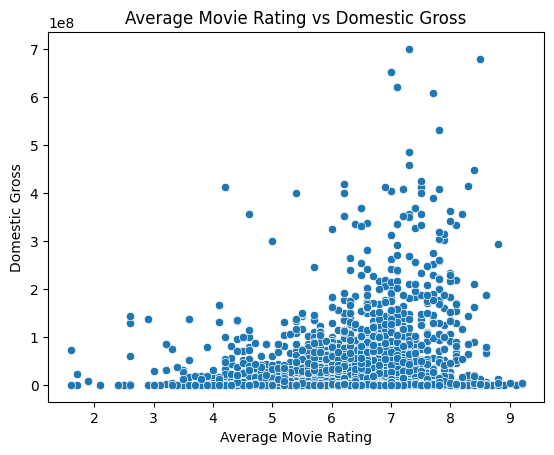

In [106]:
# plot of rating vs revenue
sns.scatterplot(data=final_df, x='average_rating', y='domestic_gross')
plt.title('Average Movie Rating vs Domestic Gross')
plt.xlabel('Average Movie Rating')
plt.ylabel('Domestic Gross')
plt.show()

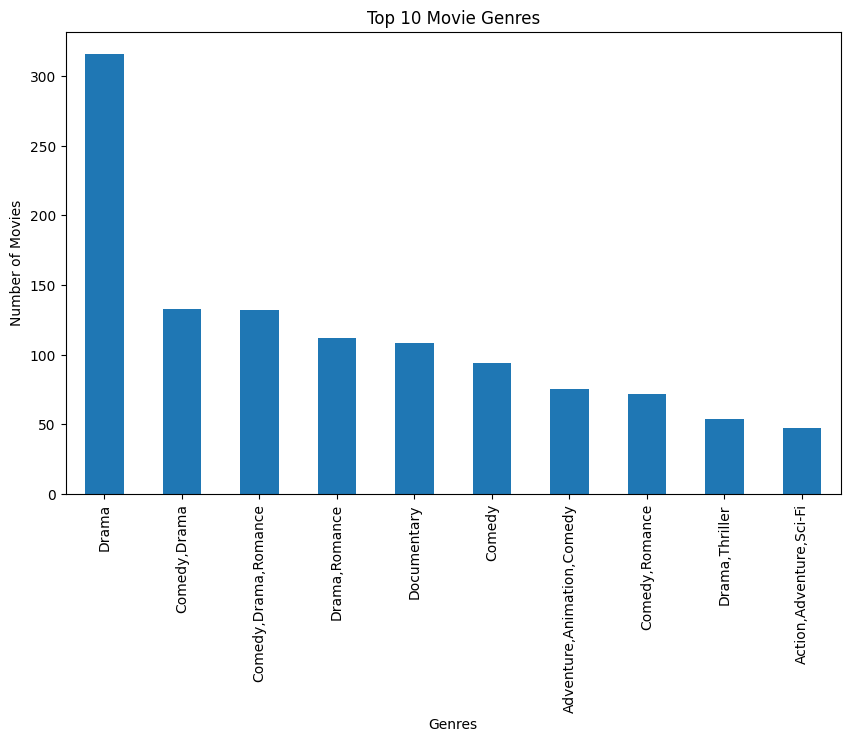

In [109]:
# bar plot of genre populatiry
plt.figure(figsize=(10, 6))
final_df['genres'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Movie Genres')
plt.xlabel('Genres')
plt.ylabel('Number of Movies')
plt.show()

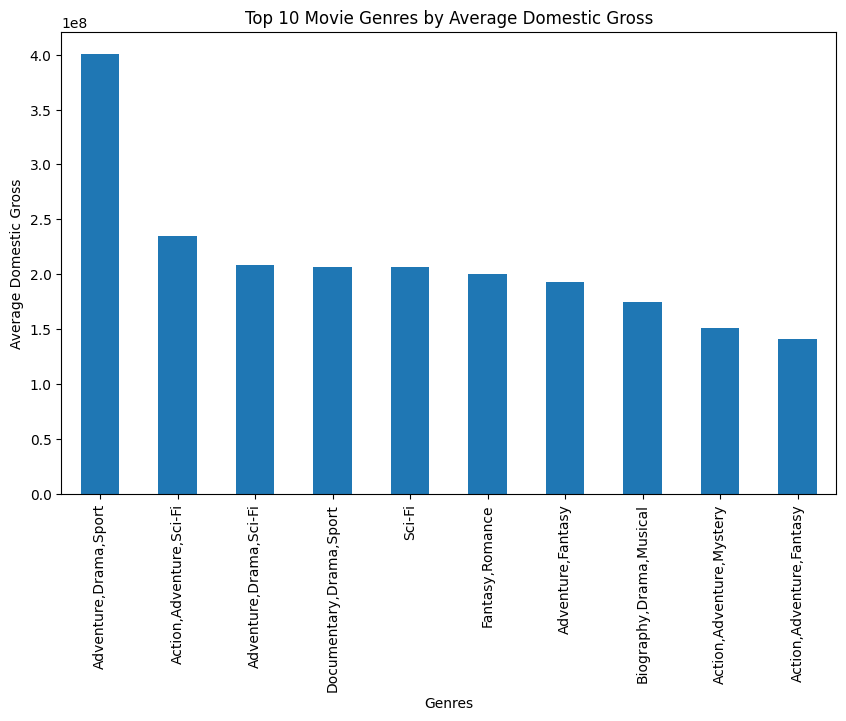

In [110]:
# plot for top genres by average domestic gross
plt.figure(figsize=(10, 6))
final_df.groupby('genres')['domestic_gross'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Movie Genres by Average Domestic Gross')
plt.xlabel('Genres')
plt.ylabel('Average Domestic Gross')
plt.show()

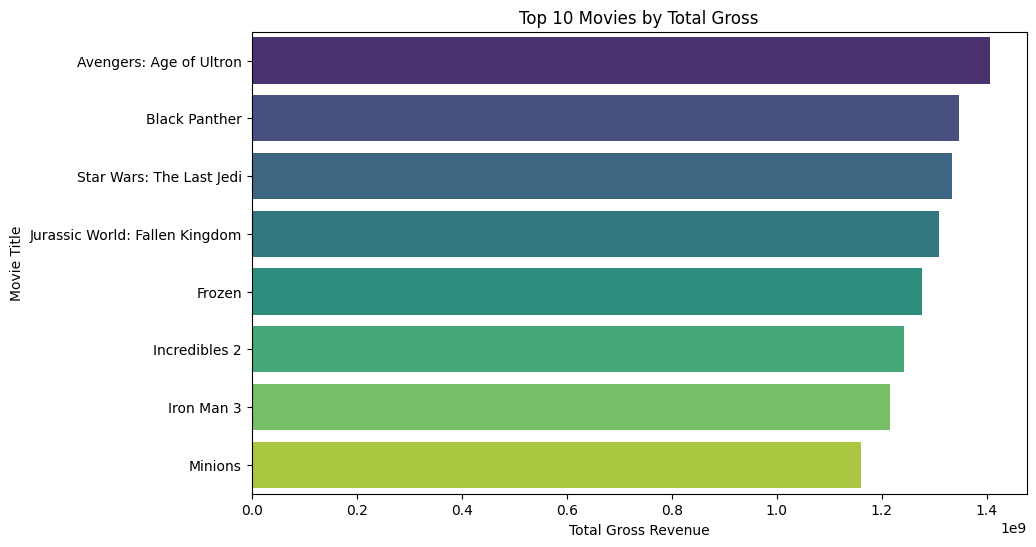

In [115]:
# plot for top 10 movies by total gross (domestic + foreign)
plt.figure(figsize=(10, 6))

# calculate total gross
final_df['total_gross'] = final_df['domestic_gross'] + final_df['foreign_gross']
top_movies = final_df.sort_values(by='total_gross', ascending=False).head(10)

# plot the top 10 movies
sns.barplot(data=top_movies, x='total_gross', y='primary_title', palette='viridis', hue='primary_title')
plt.title('Top 10 Movies by Total Gross')
plt.xlabel('Total Gross Revenue')
plt.ylabel('Movie Title')
plt.show();



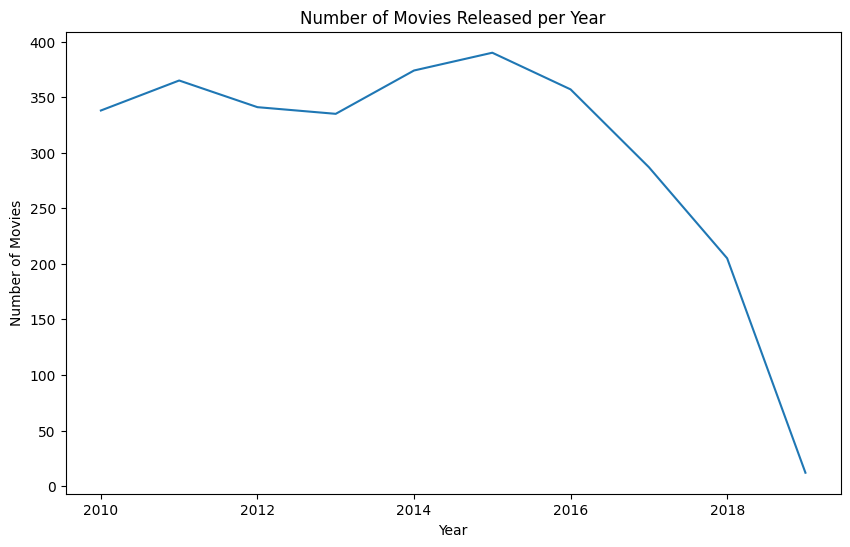

In [116]:
# plot for number o movies released per year
plt.figure(figsize=(10, 6))
final_df['start_year'] = final_df['start_year'].astype('Int64')
movies_per_year = final_df.groupby('start_year').size()

# plot
movies_per_year.plot(kind='line')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

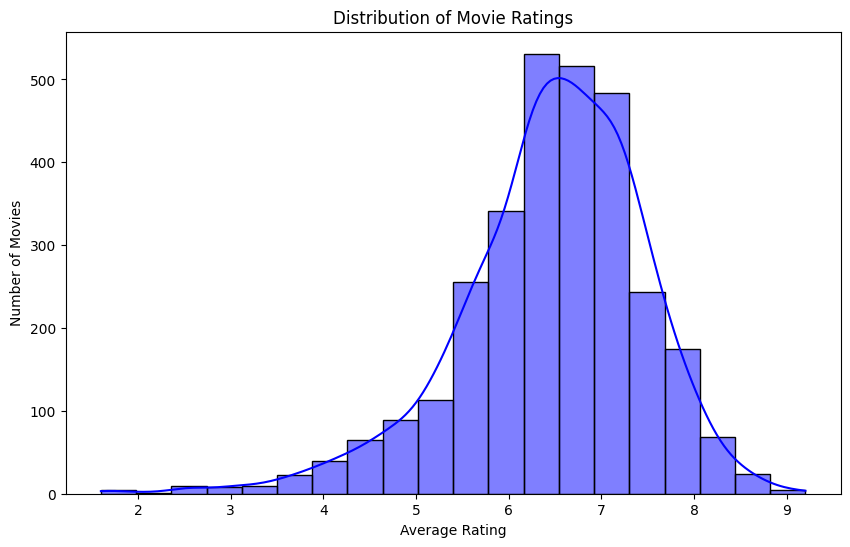

In [120]:
# plot for distribution of movie ratings
plt.figure(figsize=(10, 6))
average_rating_data = final_df['average_rating']
sns.histplot(
    data=final_df,
    x='average_rating',
    bins=20,
    kde=True,           # <<< THIS ADDS THE SMOOTH CURVE
    color='blue',
    edgecolor='black'
)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.show()


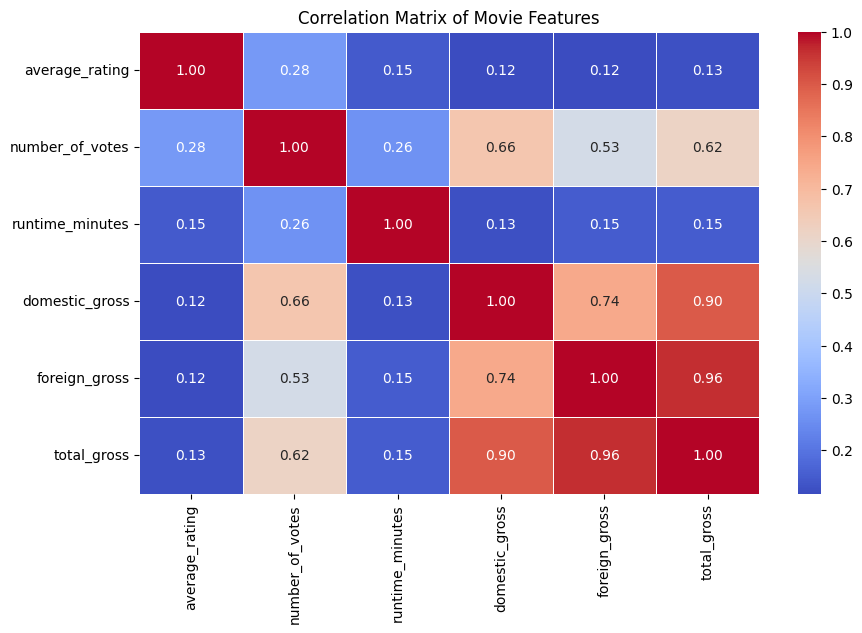

In [121]:
# heatmap for correlation matrix

# set the numeric columns
numeric_cols = ['average_rating', 'number_of_votes', 'runtime_minutes', 'domestic_gross', 'foreign_gross', 'total_gross']

# calculate the correlation matrix
corr_matrix = final_df[numeric_cols].corr()

# plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix of Movie Features')
plt.show()

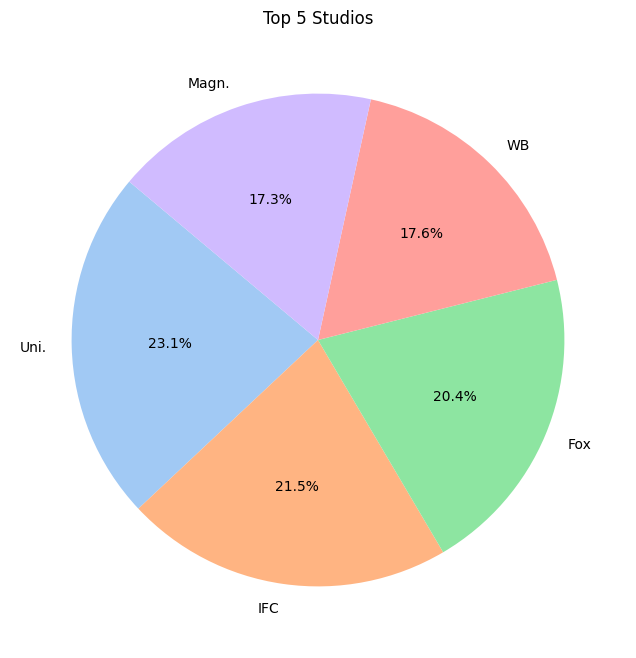

In [124]:
# pie chart for top 5 studios
plt.figure(figsize=(10,8))
top_studios = final_df['studio'].value_counts().head(5)

# plot the pie chart
top_studios.plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel', n_colors=len(top_studios))
)
plt.title('Top 5 Studios')
plt.ylabel('') # remove the y-label for cleaner look
plt.show()

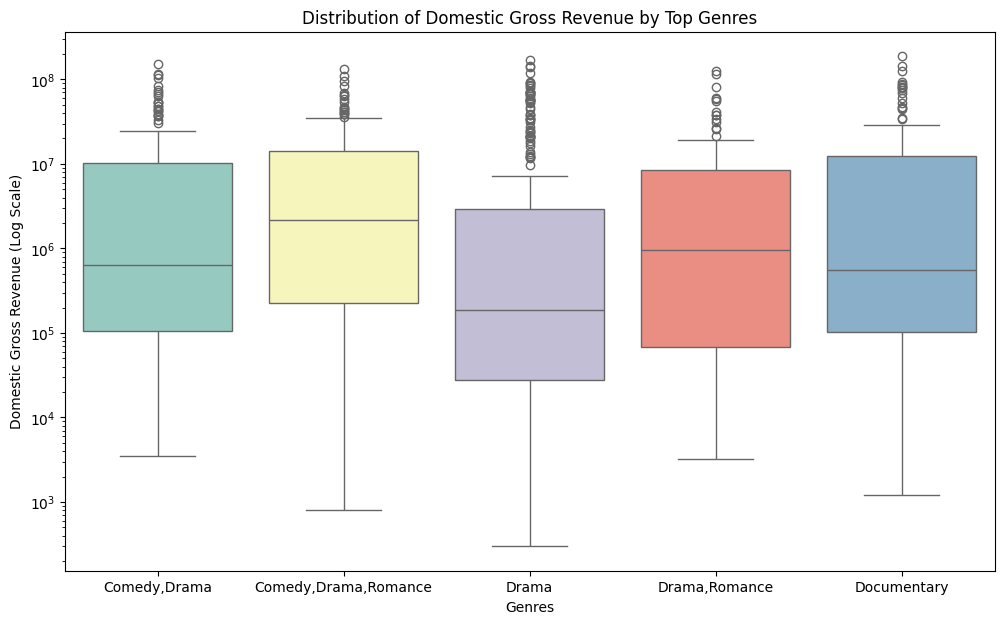

In [126]:
# plot of gross revenue distribution by genre

# select 5 genres for readability
top_genre_list = final_df['genres'].value_counts().head(5).index.tolist()

# filter data
filtered_df = final_df[final_df['genres'].isin(top_genre_list)]

# box plot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=filtered_df,
    x='genres',
    y='domestic_gross',
    palette='Set3',
    hue='genres',
    legend=False
)
plt.yscale('log')
plt.title('Distribution of Domestic Gross Revenue by Top Genres')
plt.xlabel('Genres')
plt.ylabel('Domestic Gross Revenue (Log Scale)')
plt.show()